<a href="https://colab.research.google.com/github/heoconngoc/Daily-Problems/blob/main/3_Linear_Neural_Networks_for_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# General Knowledge

In [1]:
# Setup
import math
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
# Tạo dữ liệu hồi quy tuyến tính giả

def mock_data(w, b, num_examples, noise_std=0.01):
    """
    y = Xw + b + noise
    """
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = X @ w + b
    y += torch.normal(0, noise_std, y.shape)
    return X, y.reshape(-1, 1)

true_w = torch.tensor([2.0, -3.4])
true_b = 4.2

X, y = mock_data(true_w, true_b, num_examples=1000)
X[:5], y[:5]

(tensor([[-2.7783e+00,  9.8289e-02],
         [ 1.3864e+00, -8.0743e-01],
         [-1.0922e+00, -9.4646e-01],
         [ 4.6516e-04, -8.3575e-01],
         [-2.6771e+00,  9.4543e-01]]),
 tensor([[-1.6929],
         [ 9.7295],
         [ 5.2216],
         [ 7.0379],
         [-4.3576]]))

In [5]:
batch_size = 32
dataset = TensorDataset(X, y)

loader_keep_last = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)
loader_drop_last = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print("Num batches (keep last):", len(loader_keep_last))
print("Num batches (drop last):", len(loader_drop_last))

# Check size of last batch
last_batch = list(loader_keep_last)[-1]
print("Last batch size (keep last):", last_batch[0].shape[0])

Num batches (keep last): 32
Num batches (drop last): 31
Last batch size (keep last): 8


epoch 01, loss 2.456882
epoch 02, loss 0.380677
epoch 03, loss 0.059075
epoch 04, loss 0.009068
epoch 05, loss 0.001396
epoch 06, loss 0.000257
epoch 07, loss 0.000078
epoch 08, loss 0.000052
epoch 09, loss 0.000048
epoch 10, loss 0.000047

Estimated w: [ 2.0000682 -3.3993483]
True w     : [ 2.  -3.4]
Estimated b: 4.199419975280762
True b     : 4.2


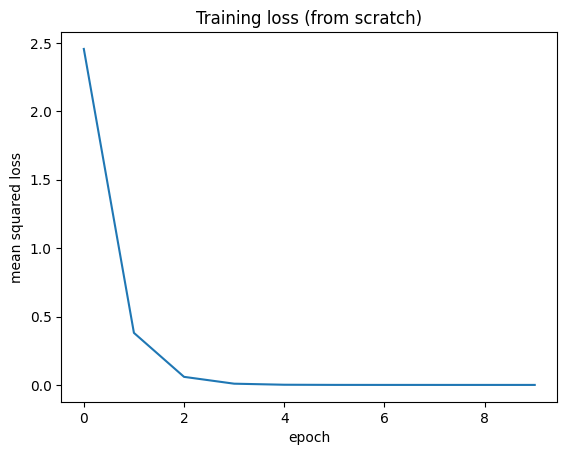

In [6]:
# Linear Regression “from scratch”

def linreg(X, w, b):
    return X @ w + b

def squared_loss(y_hat, y):
    # ensure same shape
    return 0.5 * (y_hat - y) ** 2

def sgd(params, lr, batch_size):
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad / batch_size
            p.grad.zero_()

# init params
w = torch.normal(0, 0.01, (2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.03
num_epochs = 10

train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

loss_history = []
for epoch in range(num_epochs):
    for X_batch, y_batch in train_loader:
        y_hat = linreg(X_batch, w, b)
        loss = squared_loss(y_hat, y_batch).sum()
        loss.backward()
        sgd([w, b], lr, batch_size=X_batch.shape[0])
    with torch.no_grad():
        epoch_loss = squared_loss(linreg(X, w, b), y).mean().item()
        loss_history.append(epoch_loss)
        print(f"epoch {epoch+1:02d}, loss {epoch_loss:.6f}")

print("\nEstimated w:", w.reshape(-1).detach().cpu().numpy())
print("True w     :", true_w.numpy())
print("Estimated b:", b.item())
print("True b     :", true_b)

plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("mean squared loss")
plt.title("Training loss (from scratch)")
plt.show()

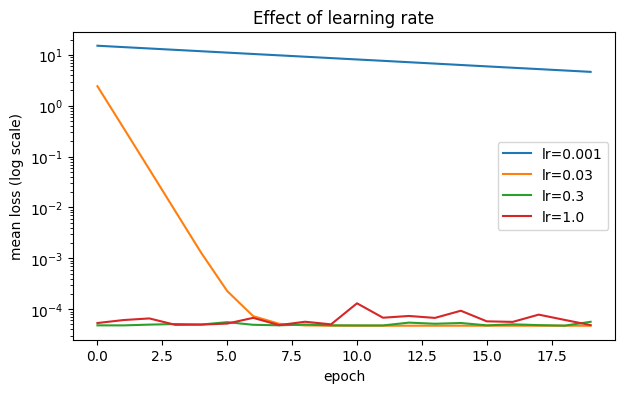

In [7]:
# Thử nhiều learning rates để thấy hội tụ / diverge

def train_from_scratch(lr, num_epochs=10):
    w = torch.normal(0, 0.01, (2, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    hist = []
    for epoch in range(num_epochs):
        for Xb, yb in train_loader:
            loss = squared_loss(linreg(Xb, w, b), yb).sum()
            loss.backward()
            sgd([w, b], lr, batch_size=Xb.shape[0])
        with torch.no_grad():
            hist.append(squared_loss(linreg(X, w, b), y).mean().item())
    return hist

lrs = [0.001, 0.03, 0.3, 1.0]
plt.figure(figsize=(7,4))
for lr_ in lrs:
    hist = train_from_scratch(lr_, num_epochs=20)
    plt.plot(hist, label=f"lr={lr_}")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("mean loss (log scale)")
plt.title("Effect of learning rate")
plt.legend()
plt.show()

epoch 01, loss 0.744228
epoch 02, loss 0.016385
epoch 03, loss 0.000440
epoch 04, loss 0.000104
epoch 05, loss 0.000095
epoch 06, loss 0.000095
epoch 07, loss 0.000095
epoch 08, loss 0.000095
epoch 09, loss 0.000095
epoch 10, loss 0.000095

Estimated w: [ 1.9999818 -3.3998141]
True w     : [ 2.  -3.4]
Estimated b: 4.199437141418457
True b     : 4.2


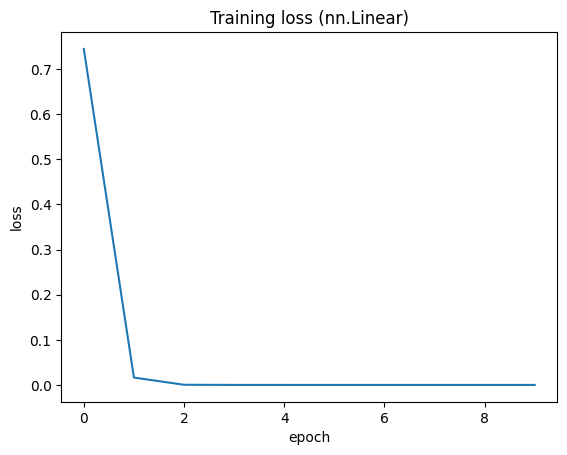

In [8]:
#  “Concise” implementation: nn.Linear + MSELoss + SGD

model = nn.Linear(2, 1).to(device)
loss_fn = nn.MSELoss(reduction="mean")
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)

train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

hist = []
for epoch in range(10):
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        y_hat = model(Xb)
        loss = loss_fn(y_hat, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        Xd, yd = X.to(device), y.to(device)
        hist.append(loss_fn(model(Xd), yd).item())
    print(f"epoch {epoch+1:02d}, loss {hist[-1]:.6f}")

w_hat = model.weight.data.detach().cpu().reshape(-1)
b_hat = model.bias.data.detach().cpu()
print("\nEstimated w:", w_hat.numpy())
print("True w     :", true_w.numpy())
print("Estimated b:", b_hat.item())
print("True b     :", true_b)

plt.plot(hist)
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Training loss (nn.Linear)")
plt.show()

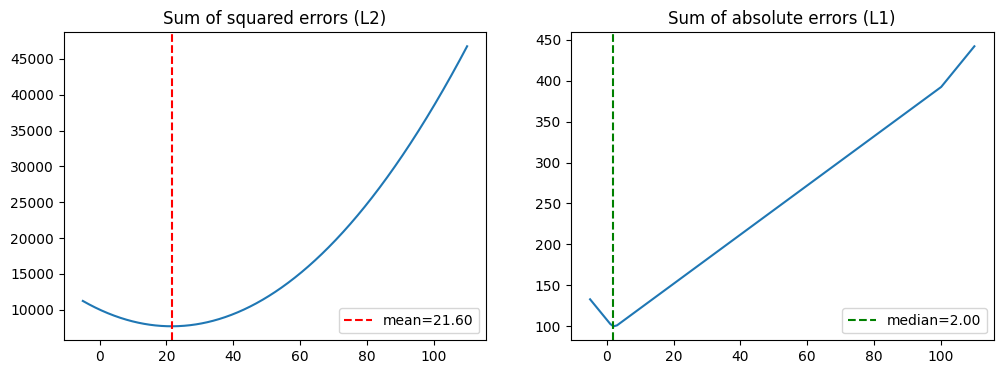

mean: 21.6 median: 2.0


In [9]:
#  Mean vs Median: minh hoạ L2 và L1 “kéo bởi outlier”

x = np.array([1, 2, 2, 3, 100])  # outlier 100
mean_b = x.mean()
median_b = np.median(x)

def L2(b): return np.sum((x - b)**2)
def L1(b): return np.sum(np.abs(x - b))

grid = np.linspace(-5, 110, 800)
L2_vals = [L2(b) for b in grid]
L1_vals = [L1(b) for b in grid]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(grid, L2_vals)
plt.axvline(mean_b, color="r", linestyle="--", label=f"mean={mean_b:.2f}")
plt.title("Sum of squared errors (L2)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(grid, L1_vals)
plt.axvline(median_b, color="g", linestyle="--", label=f"median={median_b:.2f}")
plt.title("Sum of absolute errors (L1)")
plt.legend()
plt.show()

print("mean:", mean_b, "median:", median_b)

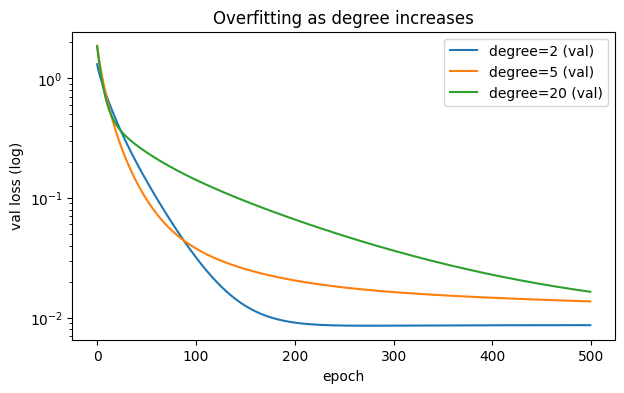

In [10]:
#  Generalization + overfitting demo
# model càng phức tạp (bậc đa thức càng cao) → train loss giảm mạnh nhưng val loss tăng (overfit)

def make_poly_features(x, degree):
    # x: (n,1) -> features: (n, degree)
    return torch.cat([x**k for k in range(1, degree+1)], dim=1)

torch.manual_seed(1)
n_train, n_val = 50, 50
x_train = torch.rand(n_train, 1) * 2 - 1
x_val   = torch.rand(n_val, 1) * 2 - 1

# true function: y = 1 + 2x - 3x^2 + noise
def f(x): return 1 + 2*x - 3*(x**2)

y_train = f(x_train) + 0.1*torch.randn_like(x_train)
y_val   = f(x_val)   + 0.1*torch.randn_like(x_val)

def train_poly(degree, wd=0.0, epochs=2000, lr=0.03):
    Xtr = make_poly_features(x_train, degree)
    Xva = make_poly_features(x_val, degree)
    model = nn.Linear(degree, 1)
    opt = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.MSELoss()

    tr_hist, va_hist = [], []
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(Xtr), y_train)
        loss.backward()
        opt.step()
        with torch.no_grad():
            tr_hist.append(loss_fn(model(Xtr), y_train).item())
            va_hist.append(loss_fn(model(Xva), y_val).item())
    return tr_hist, va_hist

degrees = [2, 5, 20]
plt.figure(figsize=(7,4))
for d in degrees:
    tr, va = train_poly(d, wd=0.0, epochs=500, lr=0.1)
    plt.plot(va, label=f"degree={d} (val)")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("val loss (log)")
plt.title("Overfitting as degree increases")
plt.legend()
plt.show()

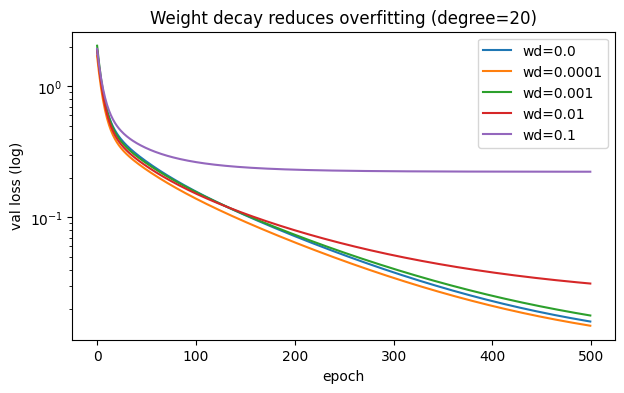

In [11]:
#  Weight decay (L2 regularization) – quét lambda

lambdas = [0.0, 1e-4, 1e-3, 1e-2, 1e-1]
plt.figure(figsize=(7,4))

for lam in lambdas:
    tr, va = train_poly(degree=20, wd=lam, epochs=500, lr=0.1)
    plt.plot(va, label=f"wd={lam}")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("val loss (log)")
plt.title("Weight decay reduces overfitting (degree=20)")
plt.legend()
plt.show()

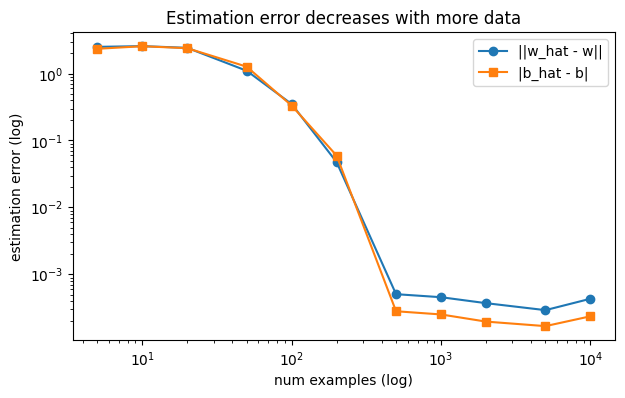

In [12]:
def estimate_error(num_examples_list, trials=5):
    errs_w, errs_b = [], []
    for n in num_examples_list:
        w_errs, b_errs = [], []
        for _ in range(trials):
            X, y = mock_data(true_w, true_b, num_examples=n, noise_std=0.01)
            ds = TensorDataset(X, y)
            dl = DataLoader(ds, batch_size=32, shuffle=True)

            model = nn.Linear(2,1)
            opt = torch.optim.SGD(model.parameters(), lr=0.03)
            loss_fn = nn.MSELoss()
            for _ in range(10):
                for Xb, yb in dl:
                    opt.zero_grad()
                    loss = loss_fn(model(Xb), yb)
                    loss.backward()
                    opt.step()

            w_hat = model.weight.data.reshape(-1)
            b_hat = model.bias.data
            w_errs.append(torch.norm(w_hat - true_w).item())
            b_errs.append(abs(b_hat.item() - true_b))
        errs_w.append(np.mean(w_errs))
        errs_b.append(np.mean(b_errs))
    return np.array(errs_w), np.array(errs_b)

num_examples_list = [5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
errs_w, errs_b = estimate_error(num_examples_list, trials=10)

plt.figure(figsize=(7,4))
plt.plot(num_examples_list, errs_w, marker="o", label="||w_hat - w||")
plt.plot(num_examples_list, errs_b, marker="s", label="|b_hat - b|")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("num examples (log)")
plt.ylabel("estimation error (log)")
plt.title("Estimation error decreases with more data")
plt.legend()
plt.show()

In [ ]:
# Create tensor
torch.zeros(2,3); # Matrix with all 0
torch.ones(2, 3); # Matrix with all 1
torch.normal(mean, std, size); # sample from Gaussian
torch.rand(3,3) # random uniform (0-1)


# Project

House Price Prediction Regression

Prediction Goal: price = w1 * area + w2 * age + w3 * num_rooms + b


In [56]:
# Setup
import math
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [57]:
# Create synthetic data
def synthetic_house_data(num_samples = 1000):
  torch.manual_seed(0); # Fixed randomness

  area = torch.normal(50, 10, (num_samples, 1)) #(mean, std, size), follow Gaussian distribution
  age = torch.normal(10, 5, (num_samples, 1))
  rooms = torch.randint(1, 5, (num_samples, 1)).float() # (low, high, size), create random num

  X = torch.cat([area, age, rooms], dim=1) # concate 3 data horizontally (dim = 1)

  # GROUND TRUTH
  w_true = torch.tensor([[3000.0], [-200.0], [5000.0]])
  b_true = 20000.0

  noise = torch.normal(0, 2000, (num_samples, 1))

  y = X @ w_true + b_true

  return X, y, w_true, b_true


In [70]:
# Train / Validation spilt

X, y, w_true, b_true = synthetic_house_data()

train_size = int(0.8 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:]
y_val = y[train_size:]

In [71]:
# Init model (w, b)

w = torch.normal(0, 0.01, (3, 1), requires_grad = True)   # Weight is always init with small value around 0
b = torch.zeros(1, requires_grad=True)

In [72]:
# Forward

def model(X, w, b):
  return X @ w + b


# Loss (MSE)

def squared_loss(y_hat, y):
  return ((y_hat - y) ** 2) / 2

# SGD
def sgd(params, lr, batch_size):
  with torch.no_grad():
    for p in params:
      p -= lr * p.grad / batch_size # p.grad is fulfilled after calling loss.backward()
      p.grad.zero_()

In [73]:
# Training loop

batch_size = 32
lr = 0.01
epochs = 50

dataset = torch.utils.data.TensorDataset(X_train, y_train) # Connect input X_train and label y_train into 1 dataset
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True) # Divide batch, shuffle dataset, and iterate easily when training

train_losses = []
val_losses = []

for epoch in range(epochs):
  for(X_batch, y_batch) in loader:

    y_hat = model(X_batch, w, b)
    loss = squared_loss(y_hat, y_batch).mean()

    loss.backward() # fulfilled w.grad and b.grad
    sgd([w, b], lr, batch_size)

  with torch.no_grad():
    train_loss = squared_loss(model(X_train, w, b), y_train).mean()
    val_loss = squared_loss(model(X_val, w, b), y_val).mean()

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

  print(f"Epoch {epoch+1}: train_loss={train_loss: .2f}, val_loss={val_loss: .2f}")


Epoch 1: train_loss= 34484956.00, val_loss= 32596008.00
Epoch 2: train_loss= 34310216.00, val_loss= 29709604.00
Epoch 3: train_loss= 31433704.00, val_loss= 28274306.00
Epoch 4: train_loss= 30155208.00, val_loss= 28395312.00
Epoch 5: train_loss= 30260936.00, val_loss= 29667782.00
Epoch 6: train_loss= 29953736.00, val_loss= 29757474.00
Epoch 7: train_loss= 28183048.00, val_loss= 27176090.00
Epoch 8: train_loss= 27805044.00, val_loss= 25849454.00
Epoch 9: train_loss= 27361950.00, val_loss= 27035254.00
Epoch 10: train_loss= 26537326.00, val_loss= 25875000.00
Epoch 11: train_loss= 28322394.00, val_loss= 25258722.00
Epoch 12: train_loss= 26175714.00, val_loss= 24229400.00
Epoch 13: train_loss= 26094366.00, val_loss= 23931066.00
Epoch 14: train_loss= 24651934.00, val_loss= 24237690.00
Epoch 15: train_loss= 24632686.00, val_loss= 23064926.00
Epoch 16: train_loss= 24401862.00, val_loss= 24798306.00
Epoch 17: train_loss= 23858010.00, val_loss= 22323804.00
Epoch 18: train_loss= 23257520.00, val_l

In [74]:
# Compare with ground truth

print("w true: ", w_true.reshape(-1)) # reshape(-1) turn it into 1-dimension-vector
print("w predicted: ", w.reshape(-1).detach()) # detach, no longer tracking from current graph

print("b true: ", b_true)
print("b predicted: ", b.item())

w true:  tensor([3000., -200., 5000.])
w predicted:  tensor([3429.0750,  158.4848, 2752.3560])
b true:  20000.0
b predicted:  430.6815490722656


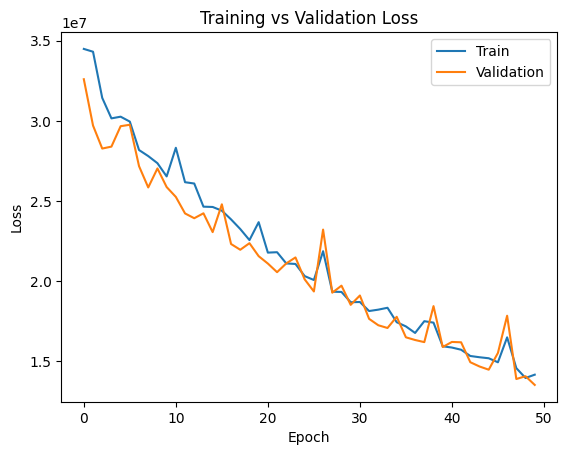

In [75]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In this project, I implemented a linear regression model from scratch using PyTorch to predict house prices based on input features.
The results show that:

Both training and validation losses consistently decrease over epochs, indicating that the model successfully learns the underlying linear relationship.

The loss curves exhibit zig-zag fluctuations, which is expected when using mini-batch SGD due to gradient noise.

Adding noise to the data improves training stability and helps prevent gradient explosion.

Hyperparameters such as learning rate and batch size significantly affect convergence speed and stability.

Although the absolute loss values remain relatively large, this is mainly due to the scale of the target variable (house prices). When evaluated using MSE, the prediction error is at a reasonable level. Therefore, a high loss value does not necessarily indicate poor model performance.

Overall, the model converges well and generalizes reasonably to the validation set, demonstrating a correct understanding and implementation of the basic machine learning training pipeline.